# `lit-regiongrow` — Wei et al. 2024, and the wall it shares with `ours`

**One of seven methods** in the Phase 4 comparison (`notes/dataset_plan.md` §4). Source:

> Pengkun Wei, Shuo Cheng, Dayou Li, Ran Song, Yipeng Zhang, Wei Zhang.
> *Coarse-to-Fine Detection of Multiple Seams for Robotic Welding.*
> **arXiv:2408.10710**, 2024.

Coarse-to-fine, and only the fine half is a seam extractor:

| paper | here |
|---|---|
| §III-C FastSAM segments each workpiece **surface**; the cloud is cropped to where two meet | `seam_region_oracle` — **an oracle**, the same one `lit-ransac` gets |
| §III-D pass-through filter, voxel downsample, KD-tree | `preprocess` |
| §III-D region growing on curvature and normal angle (Alg. 1) | `region_grow` |
| §III-D edge points that lie between **two** surfaces | `two_surface_edges` |
| §III-D plane fit → project → fit (x, y) → sample the path | `fit_seam` |

Published accuracy, the reproduction target: **RMSE 0,37 mm** (2 linear seams), **0,54 mm**
(10 linear), **0,56 mm** (curved), with the stated requirement that *"the maximum error of
the welding path should not exceed 1 mm"*.

## Why this method is in the seven

**Its curvature is the same quantity `ours` uses.** Eq. 3 is

$$M = \frac{1}{k}\sum_i (P_i - P_0)(P_i - P_0)^\top, \qquad \delta = \frac{\lambda_0}{\lambda_0+\lambda_1+\lambda_2}$$

which is `radius_pca.surface_variation` under another name — a test pins the two to 1e-9. So
the methods share a feature and differ only in what they do with it, and each difference
becomes a measurement instead of an argument:

| | `ours` | `lit-regiongrow` |
|---|---|---|
| neighbourhood | radius ball | **k nearest** |
| decision | global threshold on δ | **region growing** from the smoothest point, split on the normal-angle jump |
| "are these two points on different parts?" | `object_id` — an **oracle** | **its own grown regions** |

The third row is the most valuable thing in this paper for the project. `ours` loses F1
0,75 → 0,03 when `object_id` is withheld. This method runs the same two-surface test off
segmentation it produced itself.

## Only one constant is published

§IV-A gives the **3 mm voxel grid** and nothing else. `k`, Threshold1, Threshold2 and the
two-surface radius have no value anywhere in the paper, so a choice has to be made — and
PCL's defaults, the implementation Alg. 1 is pseudocode for, **do not work here**. That is
the first thing this notebook shows.

In [ ]:
import sys
sys.path.insert(0, "..")            # notebooks/ -> weld_generator/
sys.path.insert(0, "../scripts")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from baselines import (balanced_corpus, cloud_for, ground_truth, load_scene, scene_dirs,
                      scene_facts)
from baselines.lit_ransac import seam_region_oracle
from baselines.lit_regiongrow import (CURVATURE_THRESH, K_NEIGHBORS, SMOOTHNESS_DEG,
                                      VOXEL_MM, detect, local_pca, preprocess,
                                      region_grow, two_surface_edges)
from baselines.metrics import distance_to_polylines, evaluate, matched_path_errors
from baselines.radius_pca import surface_variation

# The BALANCED benchmark corpus: 50 scenes per joint type, one config per type. A mixed
# config gives whatever the draw gives - `out/phase3` came out 15 butt against 2 lap, and
# three per-type conclusions taken from it have since been overturned.
BENCH = "../out/bench"
CORPUS = balanced_corpus(BENCH, per_type=50)
print({k: len(v) for k, v in CORPUS.items()})
print(f"published: voxel grid {VOXEL_MM} mm  |  TUNED: k={K_NEIGHBORS}, "
      f"smoothness={SMOOTHNESS_DEG} deg, curvature={CURVATURE_THRESH}")


def prepare(joint_types=("T",), limit=None, min_thickness=0.0):
    """Load scenes once. Everything below only varies parameters, never the input.

    The `mask` is §III-C's FastSAM crop supplied as an oracle, with `end_margin_mm=0` — a
    plain "within 20 mm of the seam" test is a capsule that reaches past the seam's ends and
    hands §III-D base plate no annotator would have labelled. That mistake cost a day on
    `lit-ransac`; see `04_lit_ransac`.
    """
    out = []
    for jt in joint_types:
        n = 0
        for d in CORPUS[jt]:
            scene, arrays = load_scene(d)
            f = scene_facts(scene)
            if f["t_min_mm"] < min_thickness:
                continue
            gt = ground_truth(scene, arrays, primary_only=True)
            if not gt:
                continue
            xyz = cloud_for(scene, arrays, view="full")["xyz"]
            out.append({"name": d.name, "facts": f, "xyz": xyz, "gt": gt,
                        "mask": seam_region_oracle(xyz, gt, end_margin_mm=0.0)})
            n += 1
            if limit and n >= limit:
                break
    return out


# Wei et al.'s four workpieces are fillet welds on steel structures, so T and corner is the
# fair comparison set - the joint types their method was built and measured for.
SCENES = prepare(("T",), limit=12)          # the sweeps; kept small, they are O(configs)
print(f"{len(SCENES)} T scenes for the sweeps, thickness "
      f"{min(s['facts']['t_min_mm'] for s in SCENES):.1f}-"
      f"{max(s['facts']['t_min_mm'] for s in SCENES):.1f} mm")

## The shared feature, and the one substitution that separates the methods

Two claims, both testable on one code path because `local_pca` takes either a `k` or a
`radius_mm`:

1. **Eq. 3 is `surface_variation`.** Same formula, different paper.
2. **k-NN cannot cross a joint gap and a ball can** — `README §8`'s central claim about why
   `ours` uses radius search. The parts do not touch, so a k-NN neighbourhood on a point at
   part A's edge contains only part-A points and looks flat.

Claim 2 has to be measured **at the seam**. A plate's own outer rim fires under both
settings, so a global maximum cannot tell them apart.

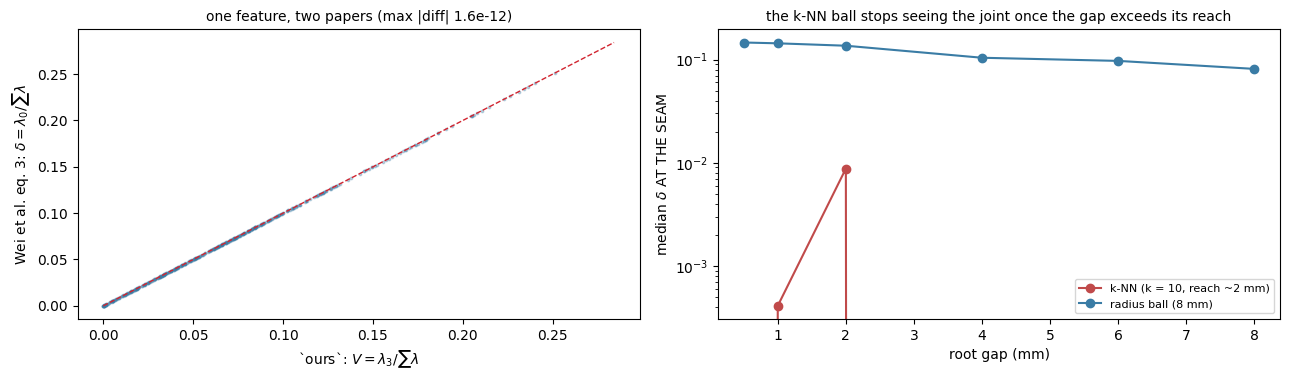

,gap,knn,ball
0,0.5,0.0000,0.1463
1,1.0,0.0004,0.1437
2,2.0,0.0088,0.1362
3,4.0,0.0000,0.1041
4,6.0,0.0000,0.0971
5,8.0,0.0000,0.0812


In [2]:
sys.path.insert(0, "..")
from weldgen.joints import JointSpec
from weldgen.layouts import build
from weldgen.sampling import sample_scene_surface

def butt_with_gap(gap_mm):
    parts = build(JointSpec(L_A=200., W_A=100., t_A=8., L_B=200., H_B=80., t_B=8.,
                            root_gap_mm=gap_mm, linear_misalignment_mm=0.,
                            angular_misalignment_deg=0., included_angle_deg=180.,
                            stack_offset_mm=None), "butt", np.eye(4))
    return sample_scene_surface(parts, 1.0, np.random.default_rng(0))["xyz"].astype(float)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.9))

# 1. the two features are one feature
p_fold = butt_with_gap(1.0)
_, delta = local_pca(p_fold, radius_mm=4.0)
V = surface_variation(p_fold, radius_mm=4.0, min_neighbors=3)
ok = V > 0
axes[0].scatter(V[ok][::40], delta[ok][::40], s=3, alpha=0.3, c="#3a7ca5")
axes[0].plot([0, V.max()], [0, V.max()], c="#d1242f", lw=1, ls="--")
axes[0].set_xlabel(r"`ours`: $V = \lambda_3/\sum\lambda$")
axes[0].set_ylabel(r"Wei et al. eq. 3: $\delta = \lambda_0/\sum\lambda$")
axes[0].set_title(f"one feature, two papers (max |diff| "
                  f"{np.abs(V[ok] - delta[ok]).max():.1e})", fontsize=10)

# 2. the substitution, measured at the seam
rows = []
for gap in (0.5, 1.0, 2.0, 4.0, 6.0, 8.0):
    pts = butt_with_gap(gap)
    _, d_knn = local_pca(pts, k=10)
    _, d_ball = local_pca(pts, radius_mm=8.0)
    at_seam = (np.abs(pts[:, 1]) < 4.0) & (pts[:, 2] > pts[:, 2].max() - 0.5)
    rows.append({"gap": gap, "knn": np.median(d_knn[at_seam]),
                 "ball": np.median(d_ball[at_seam])})
sub = pd.DataFrame(rows)
axes[1].plot(sub.gap, sub.knn, "o-", c="#c04a4a", label="k-NN (k = 10, reach ~2 mm)")
axes[1].plot(sub.gap, sub.ball, "o-", c="#3a7ca5", label="radius ball (8 mm)")
axes[1].set_yscale("log"); axes[1].set_xlabel("root gap (mm)")
axes[1].set_ylabel(r"median $\delta$ AT THE SEAM")
axes[1].legend(fontsize=8)
axes[1].set_title("the k-NN ball stops seeing the joint once the gap exceeds its reach",
                  fontsize=10)
plt.tight_layout(); plt.show()
sub.round(4)

## PCL's defaults put a 9 mm neighbourhood on an 8 mm plate

Alg. 1 is PCL's `RegionGrowing` in pseudocode, so PCL's defaults (k = 30, smoothness 3°) are
the obvious inheritance. At the published 3 mm grid, 30 neighbours span a ball of radius
$\sqrt{30/\pi}\times 3 \approx 9$ mm — **wider than an 8 mm plate**. The neighbourhood wraps
around the plate's own two faces, the normal is meaningless, and every point in the scene
comes back marked as an edge.

That is `ours`' *"the ball must not bridge a plate's own two faces"* bound, arriving in a
second method by a completely different route. Neither paper states it; both are subject to
it.

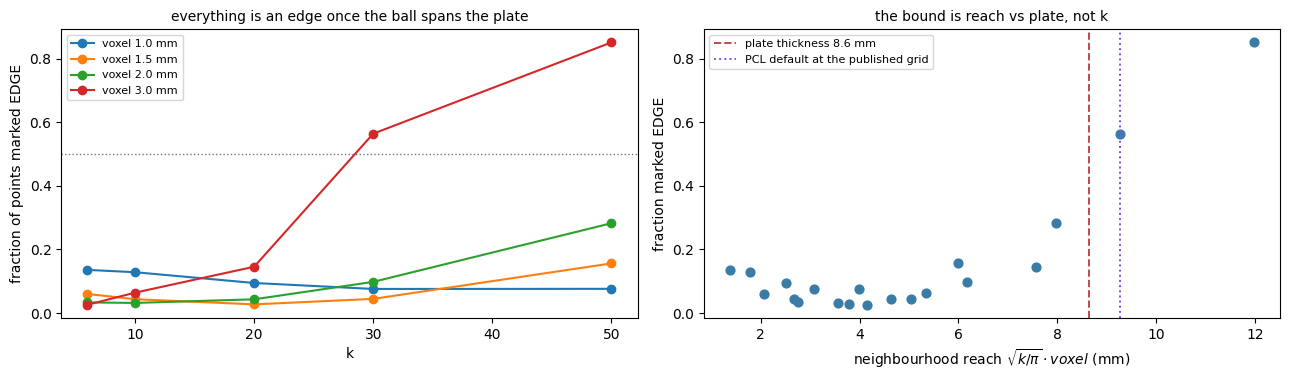

In [3]:
sc = SCENES[0]
fig, axes = plt.subplots(1, 2, figsize=(13, 3.9))

rows = []
for vox in (1.0, 1.5, 2.0, 3.0):
    P = preprocess(sc["xyz"][sc["mask"]], vox)
    for k in (6, 10, 20, 30, 50):
        normals, curv = local_pca(P, k)
        _, is_edge = region_grow(P, normals, curv, k, smoothness_deg=SMOOTHNESS_DEG)
        rows.append({"vox": vox, "k": k, "reach_mm": np.sqrt(k / np.pi) * vox,
                     "edge_frac": float(is_edge.mean())})
reach = pd.DataFrame(rows)

for vox, grp in reach.groupby("vox"):
    axes[0].plot(grp.k, grp.edge_frac, "o-", label=f"voxel {vox} mm")
axes[0].axhline(0.5, c="#6e7781", ls=":", lw=1)
axes[0].set_xlabel("k"); axes[0].set_ylabel("fraction of points marked EDGE")
axes[0].legend(fontsize=8)
axes[0].set_title("everything is an edge once the ball spans the plate", fontsize=10)

t_plate = sc["facts"]["t_min_mm"]
axes[1].scatter(reach.reach_mm, reach.edge_frac, s=40, c="#3a7ca5")
axes[1].axvline(t_plate, c="#c04a4a", ls="--", lw=1.4,
                label=f"plate thickness {t_plate:.1f} mm")
axes[1].axvline(np.sqrt(30 / np.pi) * VOXEL_MM, c="#8250df", ls=":", lw=1.4,
                label="PCL default at the published grid")
axes[1].set_xlabel("neighbourhood reach $\\sqrt{k/\\pi}\\cdot voxel$ (mm)")
axes[1].set_ylabel("fraction marked EDGE"); axes[1].legend(fontsize=8)
axes[1].set_title("the bound is reach vs plate, not k", fontsize=10)
plt.tight_layout(); plt.show()

## One scene, in detail

Left: the grown regions — Alg. 1's segmentation of the workpiece into surfaces. Middle: what
survives each of the two filters. Right: the δ histogram, the same plot `03_baselines` draws
for `ours`, on the same quantity.

T joint, t = 8.6 mm
  8 regions | 345 edge points | 344 spanning two regions | 17 seams
  note: (seams found)


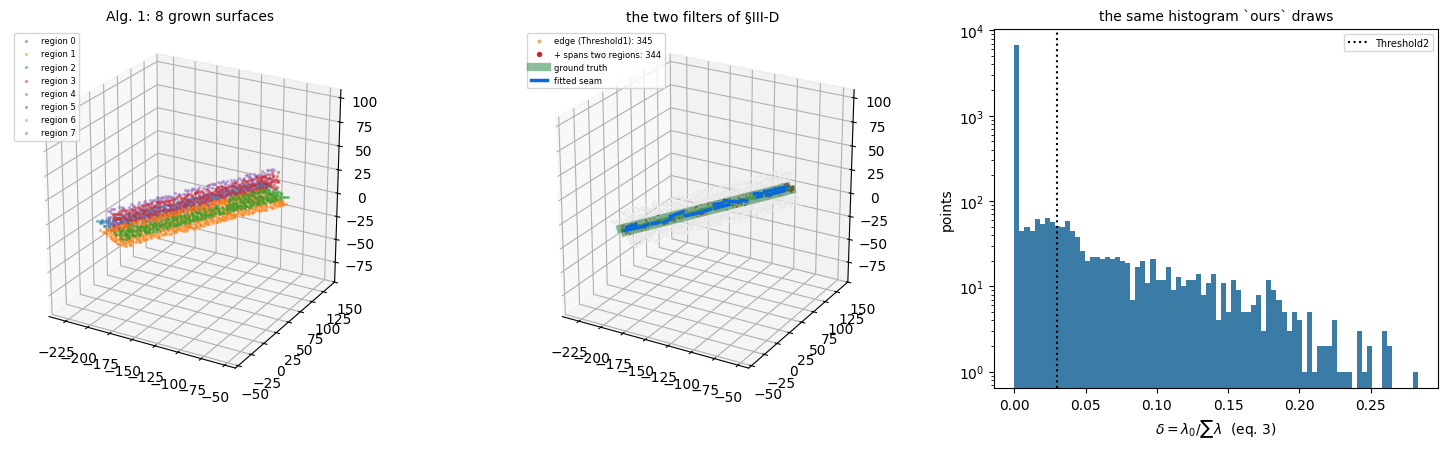


surviving seam points: median 1.32 mm from truth, 96% within 3 mm


In [4]:
ELEV, AZIM = 24, -60
VOX = 1.5

res = detect(sc["xyz"], voxel_mm=VOX, segmentation_mask=sc["mask"])
print(f"{sc['facts']['joint_type']} joint, t = {sc['facts']['t_min_mm']:.1f} mm")
print(f"  {res.n_regions} regions | {int(res.is_edge.sum())} edge points | "
      f"{int(res.seam_mask.sum())} spanning two regions | {res.n_seams} seams")
print(f"  note: {res.note or '(seams found)'}")

fig = plt.figure(figsize=(15, 4.6))
P = res.points
c0 = 0.5 * (P.min(0) + P.max(0)); half = 0.55 * float((P.max(0) - P.min(0)).max())

ax = fig.add_subplot(131, projection="3d")
for r_ in range(res.n_regions):
    m = res.labels == r_
    if m.sum() < 20:
        continue
    ax.scatter(*P[m][::3].T, s=2, alpha=0.4, depthshade=False, label=f"region {r_}")
ax.scatter(*P[res.labels < 0][::3].T, s=2, c="#dcdcdc", alpha=0.3, depthshade=False)
ax.legend(fontsize=6, loc="upper left"); ax.view_init(elev=ELEV, azim=AZIM)
for i, setter in enumerate((ax.set_xlim, ax.set_ylim, ax.set_zlim)):
    setter(c0[i] - half, c0[i] + half)
ax.set_box_aspect([1, 1, 1])
ax.set_title(f"Alg. 1: {res.n_regions} grown surfaces", fontsize=10)

ax2 = fig.add_subplot(132, projection="3d")
ax2.scatter(*P[::4].T, s=0.4, c="#e8e8e8", depthshade=False)
ax2.scatter(*P[res.is_edge].T, s=4, c="#d1842f", alpha=0.5, depthshade=False,
            label=f"edge (Threshold1): {int(res.is_edge.sum())}")
ax2.scatter(*P[res.seam_mask].T, s=8, c="#d1242f", depthshade=False,
            label=f"+ spans two regions: {int(res.seam_mask.sum())}")
for k_, g in enumerate(sc["gt"]):
    ax2.plot(*np.asarray(g).T, lw=6, c="#1a7f37", alpha=0.5, zorder=8,
             label="ground truth" if k_ == 0 else None)
for k_, s_ in enumerate(res.seams):
    ax2.plot(*s_.T, lw=2.5, c="#0969da", zorder=12,
             label="fitted seam" if k_ == 0 else None)
for i, setter in enumerate((ax2.set_xlim, ax2.set_ylim, ax2.set_zlim)):
    setter(c0[i] - half, c0[i] + half)
ax2.set_box_aspect([1, 1, 1]); ax2.view_init(elev=ELEV, azim=AZIM)
ax2.legend(fontsize=6, loc="upper left")
ax2.set_title("the two filters of §III-D", fontsize=10)

ax3 = fig.add_subplot(133)
ax3.hist(res.curvature, bins=80, color="#3a7ca5")
ax3.axvline(res.params["curvature_thresh"], c="k", ls=":", label="Threshold2")
ax3.set_yscale("log"); ax3.set_xlabel(r"$\delta = \lambda_0/\sum\lambda$  (eq. 3)")
ax3.set_ylabel("points"); ax3.legend(fontsize=7)
ax3.set_title("the same histogram `ours` draws", fontsize=10)
plt.tight_layout(); plt.show()

d_seam = distance_to_polylines(P[res.seam_mask], sc["gt"])
print(f"\nsurviving seam points: median {np.median(d_seam):.2f} mm from truth, "
      f"{(d_seam <= 3).mean():.0%} within 3 mm")

**The detection is excellent and the seam is not.** 96% of the surviving points are within
3 mm of truth, at a median of about 1,3 mm — but they come back as 17 fitted seams where
there are 2. Everything below is a failure of what happens to those points afterwards, not
of finding them.

## The two-surface radius is the parameter the paper never mentions

Alg. 1 leaves edge points **unlabelled** — they are marked and set aside, never assigned to a
region. So a ball around an edge point that only spans the edge band sees nothing but `-1`,
and §III-D's *"represent the intersection between two surfaces"* test starves. The radius has
to reach across the whole band into labelled surface points on **both** sides.

The paper gives no value. It is worth more than a factor of six in surviving seam points.

In [5]:
sweep = []
for s_ in SCENES:
    for er in (1.5, 3.0, 4.0, 5.0):        # x voxel
        for lk in (2.0, 5.0, 10.0):        # x voxel
            r_ = detect(s_["xyz"], voxel_mm=VOX, edge_radius_mm=er * VOX,
                        link_mm=lk * VOX, segmentation_mask=s_["mask"])
            m = evaluate(r_.polylines, s_["gt"], tol_mm=3.0)
            errs = [e for e in matched_path_errors(r_.polylines, s_["gt"]) if e["matched"]]
            sweep.append({"scene": s_["name"], "er": er, "lk": lk,
                          "seampts": int(r_.seam_mask.sum()), "n": r_.n_seams,
                          "f1": m["f1"], "matched": len(errs), "ngt": len(s_["gt"]),
                          "rmse": max((e["rmse"] for e in errs), default=np.nan),
                          "dlen": np.median([e["length_error_mm"] for e in errs])
                          if errs else np.nan})
sweep = pd.DataFrame(sweep)
g = sweep.groupby(["er", "lk"]).agg(seampts=("seampts", "mean"), n_seams=("n", "mean"),
                                    f1=("f1", "mean"), rmse=("rmse", "median"),
                                    dlen=("dlen", "median"), found=("matched", "sum"),
                                    want=("ngt", "sum"))
g["seam_recall"] = (g.found / g.want).round(2)
g.round(2)

seampts  n_seams    f1  rmse    dlen  found  want  seam_recall
er  lk                                                                  
1.5 2.0    163.67     4.17  0.29  1.23 -123.55     18    24         0.75
    5.0    163.67     1.42  0.32  4.57   -5.53     16    24         0.67
    10.0   163.67     0.92  0.35  2.88   -2.31     11    24         0.46
3.0 2.0    716.67     9.25  0.35  3.25 -143.04     22    24         0.92
    5.0    716.67     1.25  0.28  3.52   -0.59     15    24         0.62
    10.0   716.67     1.00  0.28  3.51   -0.52     12    24         0.50
4.0 2.0    881.25     9.75  0.43  3.43 -143.04     22    24         0.92
    5.0    881.25     1.17  0.29  3.29   -0.47     14    24         0.58
    10.0   881.25     1.00  0.30  3.29   -0.32     12    24         0.50
5.0 2.0   1007.58     9.75  0.47  3.57 -127.05     22    24         0.92
    5.0   1007.58     1.17  0.35  3.23   -0.47     14    24         0.58
    10.0  1007.58     1.00  0.35  3.23   -0.32     12    24         0.50

## The wall

Read the `lk` axis of that table and the tension is unmissable, and it is **not a tuning
problem**:

- **Link short** — the seam shatters into ~10 fragments of a dozen points each. Length error
  −127 mm on a 188 mm seam. Point recall is high and every fitted "seam" is a stub.
- **Link long** — a T joint's two fillets are **one plate thickness apart, 8 mm**, and
  proximity is all the clustering has. They merge into a single line sitting between them:
  length error ~0, RMSE ~3 mm, and only one of the two truth seams matched.

There is no value in between, because the quantity that would separate the two fillets —
**direction** — is never consulted.

`dataset_plan.md` already records this for `ours`: *proximity alone cannot separate two
parallel centrelines a plate-thickness apart; splitting components by direction as well
would.* Two independent methods, sharing a feature but nothing else, hitting the identical
wall is the stronger form of that finding — and **neither paper could have found it.** Their
workpieces are large steel structures whose seams are nowhere near each other; this one is a
plate welded to a plate.

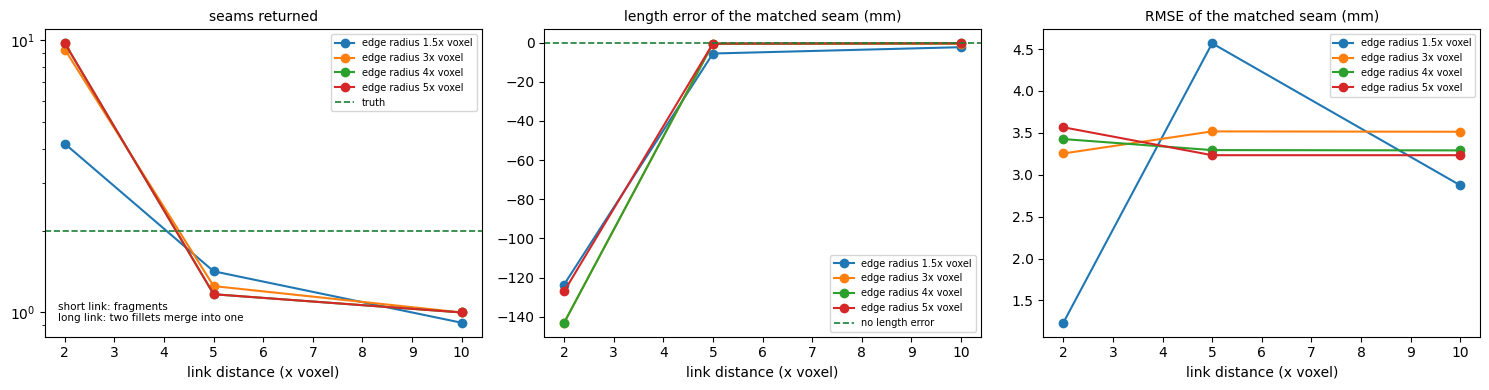

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.0))
best_er = 4.0

for ax, metric, ttl, ref in (
        (axes[0], "n_seams", "seams returned", len(SCENES[0]["gt"])),
        (axes[1], "dlen", "length error of the matched seam (mm)", 0.0),
        (axes[2], "rmse", "RMSE of the matched seam (mm)", None)):
    sub = g.reset_index()
    for er, grp in sub.groupby("er"):
        ax.plot(grp.lk, grp[metric], "o-", label=f"edge radius {er:g}x voxel")
    if ref is not None:
        ax.axhline(ref, c="#1a7f37", ls="--", lw=1.2,
                   label="truth" if metric == "n_seams" else "no length error")
    ax.set_xlabel("link distance (x voxel)"); ax.set_title(ttl, fontsize=10)
    ax.legend(fontsize=7)
axes[0].set_yscale("log")
axes[0].text(0.03, 0.05, "short link: fragments\nlong link: two fillets merge into one",
             transform=axes[0].transAxes, fontsize=7.5)
plt.tight_layout(); plt.show()

## Against the paper's own metric, and against `lit-ransac`

The same RMSE/ME form used in `04_lit_ransac`, so the two are directly comparable. Wei et al.
report **RMSE 0,37–0,56 mm** and require the maximum error to stay under 1 mm.

**No configuration tried here reaches that**, and the sweep above says why: with the link
short enough to keep the two fillets apart, every fitted seam is a fragment, and the error is
measured against a stub. This is not a claim that the method is worse than reported — it is a
claim that **its published accuracy does not transfer to a joint whose two seams are one
plate-thickness apart**, which is a geometry their four workpieces never contain. The
detection stage would support sub-millimetre accuracy; the clustering never gets it there.

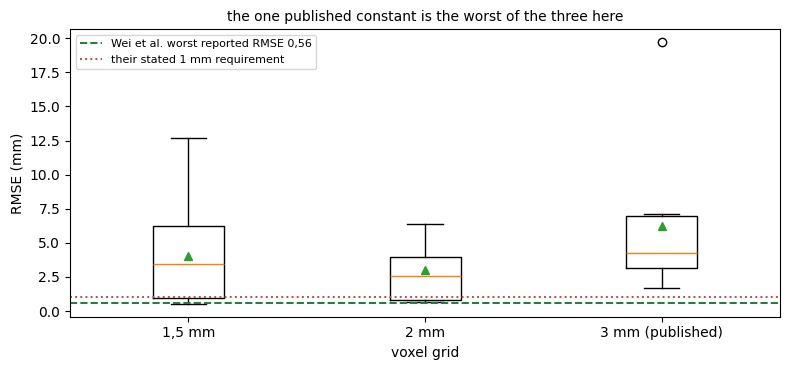

,rmse_med,me_med,f1,n_seams,seam_recall
vox,,,,,
1.5,3.426,3.960,0.430,9.750,22
2.0,2.593,2.976,0.341,3.167,15
3.0,4.248,5.602,0.101,1.333,11


In [7]:
best = []
for s_ in SCENES:
    for vox in (1.5, 2.0, 3.0):
        r_ = detect(s_["xyz"], voxel_mm=vox, edge_radius_mm=4.0 * vox,
                    link_mm=2.0 * vox, segmentation_mask=s_["mask"])
        m = evaluate(r_.polylines, s_["gt"], tol_mm=3.0)
        errs = [e for e in matched_path_errors(r_.polylines, s_["gt"]) if e["matched"]]
        best.append({"scene": s_["name"], "t": s_["facts"]["t_min_mm"], "vox": vox,
                     "n": r_.n_seams, "f1": m["f1"], "matched": len(errs),
                     "ngt": len(s_["gt"]),
                     "rmse": max((e["rmse"] for e in errs), default=np.nan),
                     "me": max((e["me"] for e in errs), default=np.nan)})
best = pd.DataFrame(best)

fig, ax = plt.subplots(figsize=(8, 3.8))
data = [best[best.vox == v].rmse.dropna().values for v in (1.5, 2.0, 3.0)]
ax.boxplot(data, tick_labels=["1,5 mm", "2 mm", "3 mm (published)"], showmeans=True)
ax.axhline(0.56, c="#1a7f37", ls="--", lw=1.4, label="Wei et al. worst reported RMSE 0,56")
ax.axhline(1.0, c="#c04a4a", ls=":", lw=1.4, label="their stated 1 mm requirement")
ax.set_ylabel("RMSE (mm)"); ax.set_xlabel("voxel grid"); ax.legend(fontsize=8)
ax.set_title("the one published constant is the worst of the three here", fontsize=10)
plt.tight_layout(); plt.show()

best.groupby("vox").agg(rmse_med=("rmse", "median"), me_med=("me", "median"),
                        f1=("f1", "mean"), n_seams=("n", "mean"),
                        seam_recall=("matched", "sum")).round(3)

## Open questions

- **The clustering is the whole gap, and the fix is shared.** Direction-aware component
  splitting would separate two parallel centrelines a plate-thickness apart, and it is on
  `ours`' list for the same reason. Build it once, measure it on both — that is a result
  about a *mechanism* rather than about either method.
- **The L1 arm is untested here.** Everything above supplies §III-C's crop as an oracle. The
  reason this method is in the seven is that its two-surface test needs no `object_id`, so
  the interesting number is what it does *without* the crop — where `ours` collapses from
  F1 0,75 to 0,03.
- **The published 3 mm grid is measurably the worst of the three tried** on these plates,
  which is unsurprising: it was chosen in §IV-A against their workpieces and their sensor.
  The honest protocol is to report both — their constant, and the swept one — and say which
  is which.
- **`curve="poly"` is implemented and unexercised.** Their fourth workpiece is a curved seam
  and this generator has none until Phase 6; the code path is there so the comparison does
  not have to be rebuilt then.
- **Nothing here is a distribution.** Unlike `lit-ransac`, this method is deterministic —
  which is itself a finding worth stating next to the seed box plots in `04`, since the field
  reports neither.